/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_26439/2595255063.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels, widths=0.5)


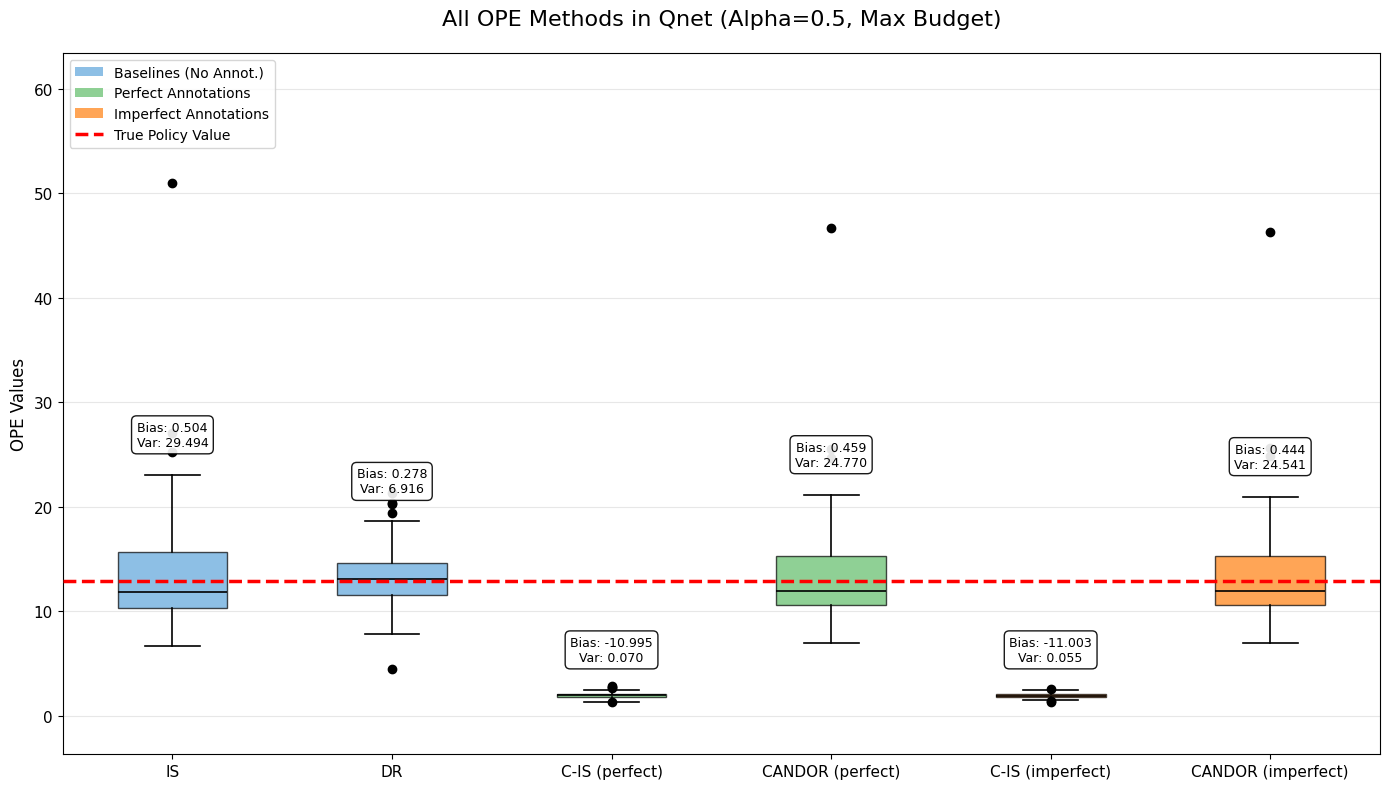

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


data = np.load('boxplot_data_mdp_qnet.npz', allow_pickle=True)

true_value = float(data['true_value'])
alphas = data['alphas']
budgets = data['budgets']

target_alpha = 0.5
alpha_idx = np.argmin(np.abs(alphas - target_alpha))
budget_idx = -1

est_is = data['PDIS_estimates']
est_dr = data['DR_estimates']

est_cis_perf = data['CPDIS_perfect_estimates'][:, alpha_idx, budget_idx]
est_candor_perf = data['CANDOR_perfect_estimates'][:, alpha_idx, budget_idx]

est_cis_imp = data['CPDIS_imperfect_estimates'][:, alpha_idx, budget_idx]
est_candor_imp = data['CANDOR_imperfect_estimates'][:, alpha_idx, budget_idx]

box_data = [est_is, est_dr, est_cis_perf, est_candor_perf, est_cis_imp, est_candor_imp]
labels = ['IS', 'DR', 'C-IS (perfect)', 'CANDOR (perfect)', 'C-IS (imperfect)', 'CANDOR (imperfect)']

colors = ['#5da5da', '#5da5da', '#60bd68', '#60bd68', '#ff7f0e', '#ff7f0e']

fig, ax = plt.subplots(figsize=(14, 8))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels, widths=0.5)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        item.set_linewidth(1.2)
        if key == 'fliers':
            item.set_marker('o')
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(6)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2.5, label='True Value', zorder=10)

global_max = np.max([np.max(d) for d in box_data])
global_min = np.min([np.min(d) for d in box_data])
y_range = global_max - global_min
y_offset = y_range * 0.05

for i, estimates in enumerate(box_data):
    mean_est = np.mean(estimates)
    bias = mean_est - true_value
    variance = np.var(estimates)

    upper_whisker = bp['whiskers'][i*2 + 1].get_ydata()[1]

    text_y = upper_whisker + y_offset

    ax.text(i + 1, text_y,
            f'Bias: {bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='normal',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='black'))

legend_elements = [
    Patch(facecolor='#5da5da', alpha=0.7, label='Baselines (No Annot.)'),
    Patch(facecolor='#60bd68', alpha=0.7, label='Perfect Annotations'),
    Patch(facecolor='#ff7f0e', alpha=0.7, label='Imperfect Annotations'),
    Line2D([0], [0], color='red', linestyle='--', lw=2.5, label='True Policy Value')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=10, frameon=True)

ax.set_title(f'All OPE Methods in Qnet (Alpha={target_alpha}, Max Budget)', fontsize=16, pad=20)
ax.set_ylabel('OPE Values', fontsize=12)
ax.grid(True, linestyle='-', alpha=0.3, axis='y')

plt.ylim([global_min - y_range*0.1, global_max + y_range*0.25])

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('All_OPEs_qnet.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_26439/24909959.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels, widths=0.5)


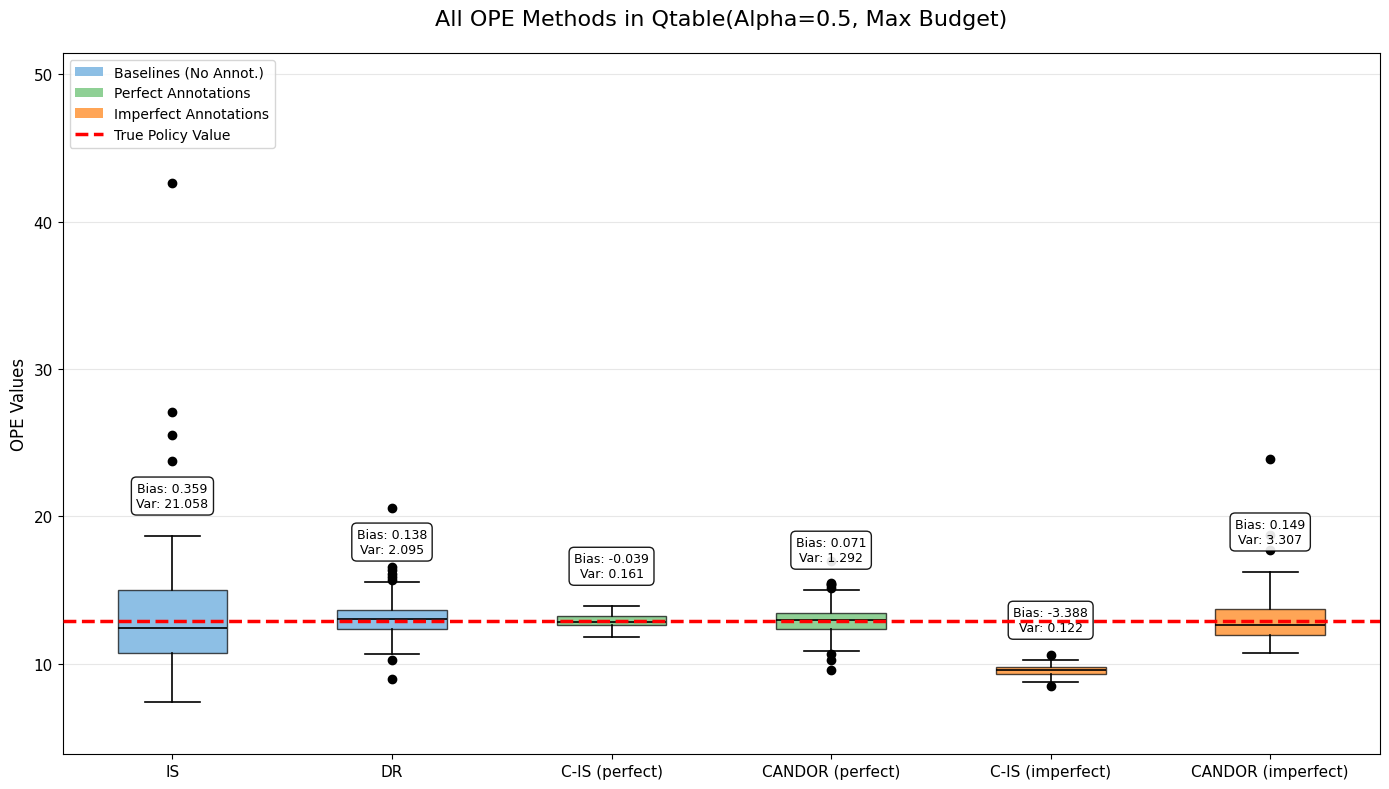

In [4]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)

true_value = float(data['true_value'])
alphas = data['alphas']
budgets = data['budgets']

target_alpha = 0.5
alpha_idx = np.argmin(np.abs(alphas - target_alpha))
budget_idx = -1

est_is = data['PDIS_estimates']
est_dr = data['DR_estimates']

est_cis_perf = data['CPDIS_perfect_estimates'][:, alpha_idx, budget_idx]
est_candor_perf = data['CANDOR_perfect_estimates'][:, alpha_idx, budget_idx]

est_cis_imp = data['CPDIS_imperfect_estimates'][:, alpha_idx, budget_idx]
est_candor_imp = data['CANDOR_imperfect_estimates'][:, alpha_idx, budget_idx]

box_data = [est_is, est_dr, est_cis_perf, est_candor_perf, est_cis_imp, est_candor_imp]
labels = ['IS', 'DR', 'C-IS (perfect)', 'CANDOR (perfect)', 'C-IS (imperfect)', 'CANDOR (imperfect)']

colors = ['#5da5da', '#5da5da', '#60bd68', '#60bd68', '#ff7f0e', '#ff7f0e']

fig, ax = plt.subplots(figsize=(14, 8))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels, widths=0.5)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        item.set_linewidth(1.2)
        if key == 'fliers':
            item.set_marker('o')
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(6)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2.5, label='True Value', zorder=10)

global_max = np.max([np.max(d) for d in box_data])
global_min = np.min([np.min(d) for d in box_data])
y_range = global_max - global_min
y_offset = y_range * 0.05

for i, estimates in enumerate(box_data):
    mean_est = np.mean(estimates)
    bias = mean_est - true_value
    variance = np.var(estimates)

    upper_whisker = bp['whiskers'][i*2 + 1].get_ydata()[1]

    text_y = upper_whisker + y_offset

    ax.text(i + 1, text_y,
            f'Bias: {bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='normal',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='black'))

legend_elements = [
    Patch(facecolor='#5da5da', alpha=0.7, label='Baselines (No Annot.)'),
    Patch(facecolor='#60bd68', alpha=0.7, label='Perfect Annotations'),
    Patch(facecolor='#ff7f0e', alpha=0.7, label='Imperfect Annotations'),
    Line2D([0], [0], color='red', linestyle='--', lw=2.5, label='True Policy Value')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=10, frameon=True)

ax.set_title(f'All OPE Methods in Qtable(Alpha={target_alpha}, Max Budget)', fontsize=16, pad=20)
ax.set_ylabel('OPE Values', fontsize=12)
ax.grid(True, linestyle='-', alpha=0.3, axis='y')

plt.ylim([global_min - y_range*0.1, global_max + y_range*0.25])

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('All_OPEs_Qtable.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_26439/753308050.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


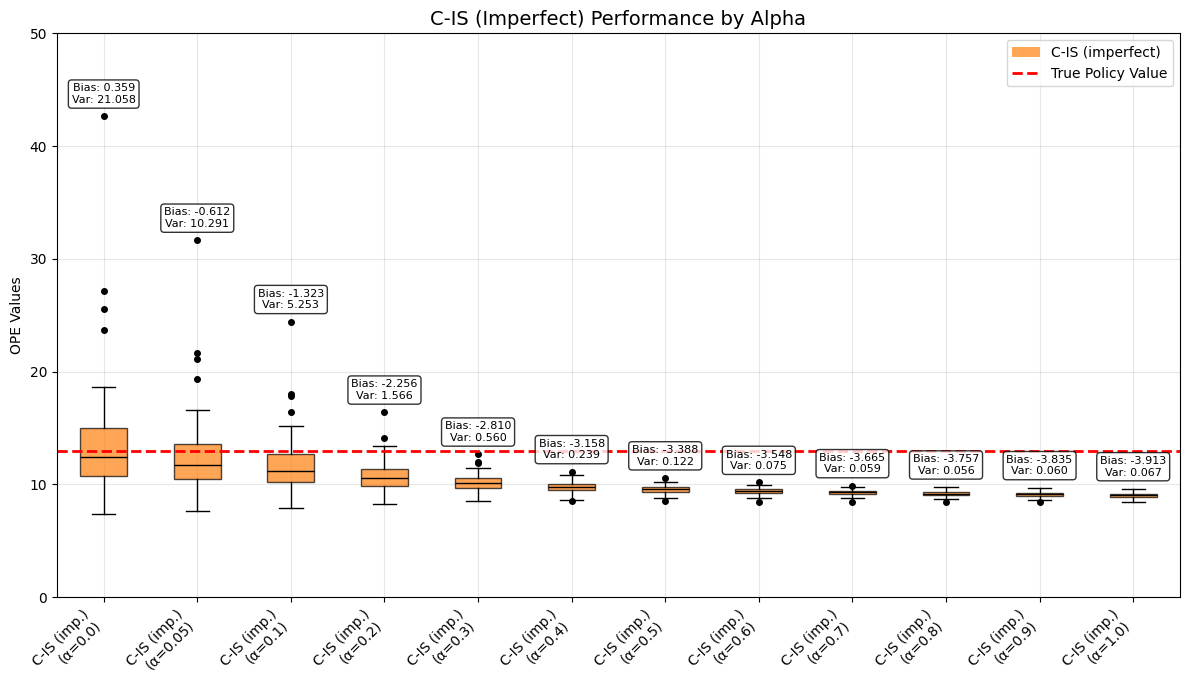

In [13]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

cis_imperfect_data = data['CPDIS_imperfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(cis_imperfect_data[:, i, -1])
    labels.append(f'C-IS (imp.)\n(α={alpha})')

color = '#ff7f0e'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#ff7f0e', alpha=0.7, label='C-IS (imperfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('C-IS (Imperfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.ylim([0,50])
plt.tight_layout()
plt.savefig('C-IS (Imperfect) Alpha Boxplot.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_26439/311956694.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


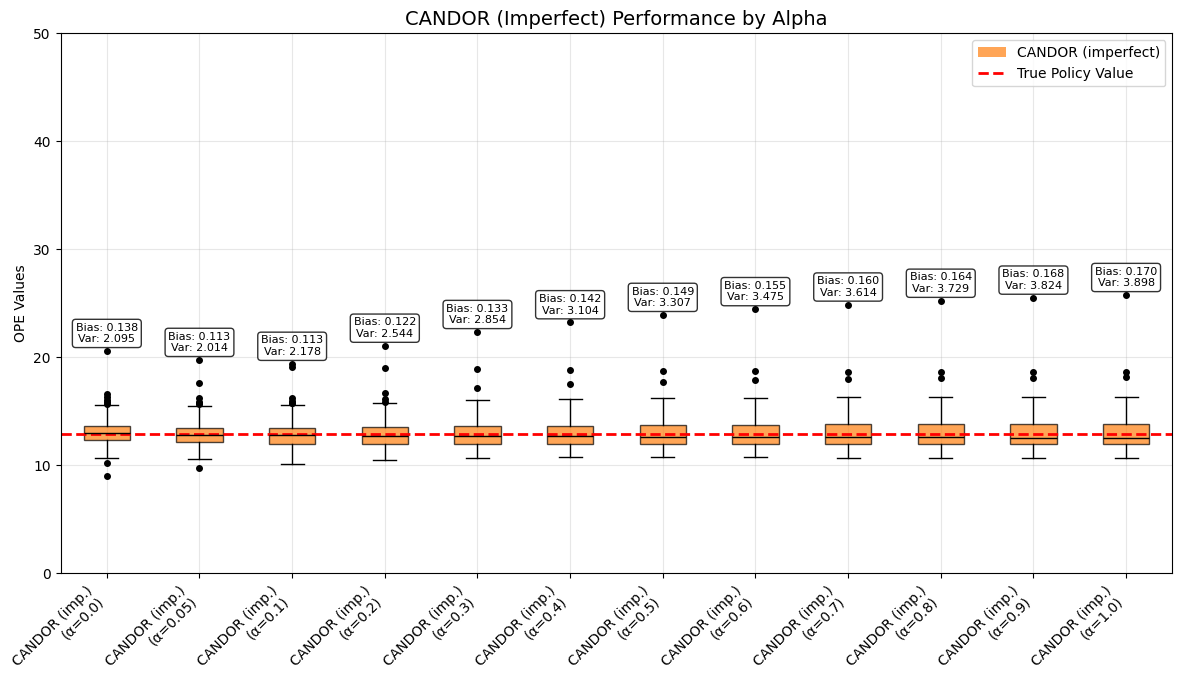

In [11]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

candor_imperfect_data = data['CANDOR_imperfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(candor_imperfect_data[:, i, -1])
    labels.append(f'CANDOR (imp.)\n(α={alpha})')

color = '#ff7f0e'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#ff7f0e', alpha=0.7, label='CANDOR (imperfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('CANDOR (Imperfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)

plt.xticks(rotation=45, ha='right')

plt.ylim([0,50])
plt.tight_layout()
plt.savefig('CANDOR(Imperfect) Alpha Boxplot.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_26439/792064127.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


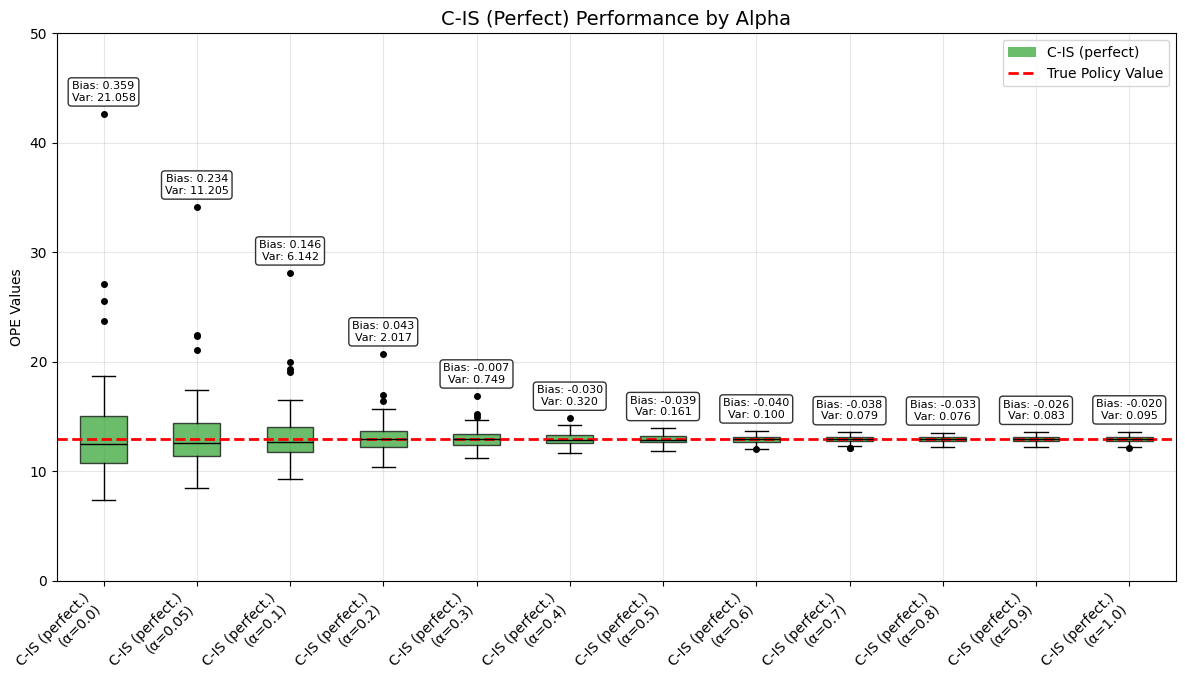

In [14]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

cis_imperfect_data = data['CPDIS_perfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(cis_imperfect_data[:, i, -1])
    labels.append(f'C-IS (perfect.)\n(α={alpha})')

color = '#2ca02c'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#2ca02c', alpha=0.7, label='C-IS (perfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('C-IS (Perfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.ylim([0,50])
plt.tight_layout()
plt.savefig('C-IS (Perfect) Alpha Boxplot.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_26439/2334397669.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


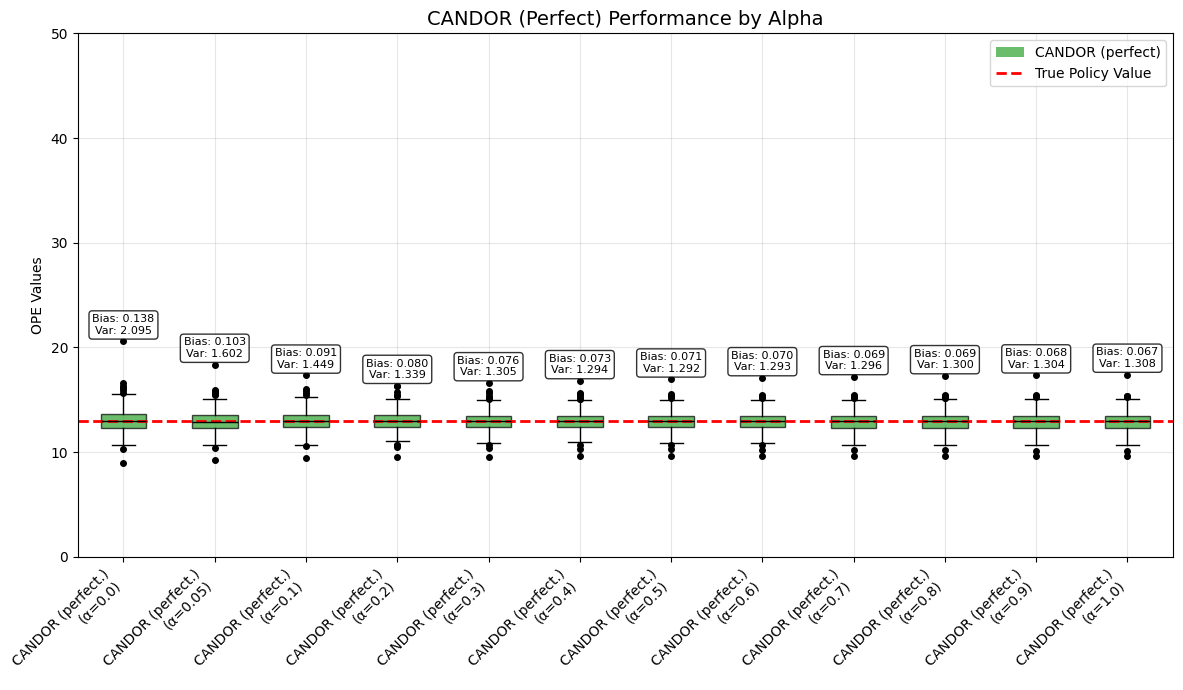

In [15]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

candor_perfect_data = data['CANDOR_perfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(candor_perfect_data[:, i, -1])
    labels.append(f'CANDOR (perfect.)\n(α={alpha})')

color = '#2ca02c'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#2ca02c', alpha=0.7, label='CANDOR (perfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('CANDOR (Perfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)
plt.ylim([0, 6])

plt.xticks(rotation=45, ha='right')
plt.ylim([0,50])
plt.tight_layout()
plt.savefig('CANDOR (Perfect) Alpha Boxplot.png', dpi=300)
plt.show()

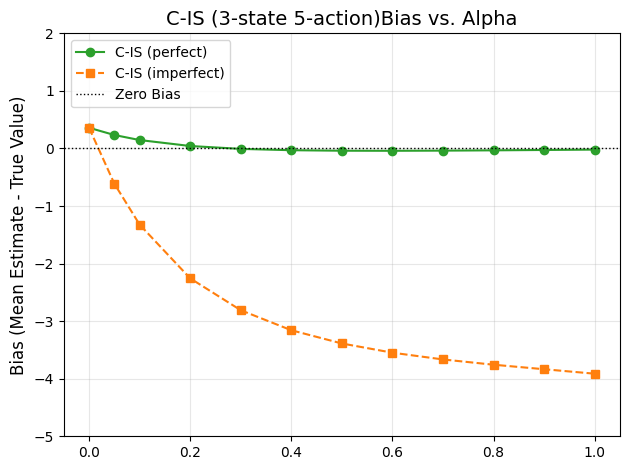

In [19]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
imperfect_data_max_budget = data['CPDIS_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CPDIS_perfect_estimates'][:, :, -1]

imperfect_bias = np.mean(imperfect_data_max_budget, axis=0) - true_value
perfect_bias = np.mean(perfect_data_max_budget, axis=0) - true_value

plt.plot(alphas, perfect_bias, marker='o', linestyle='-', color='#2ca02c', label='C-IS (perfect)')
plt.plot(alphas, imperfect_bias, marker='s', linestyle='--', color='#ff7f0e', label='C-IS (imperfect)')

plt.axhline(y=0, color='black', linestyle=':', linewidth=1, label='Zero Bias')

plt.title(f'C-IS (3-state 5-action)Bias vs. Alpha', fontsize=14)
plt.ylabel('Bias (Mean Estimate - True Value)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-5, 2])
plt.tight_layout()
plt.savefig('CIS_Bias_Alpha.png', dpi=300)
plt.show()

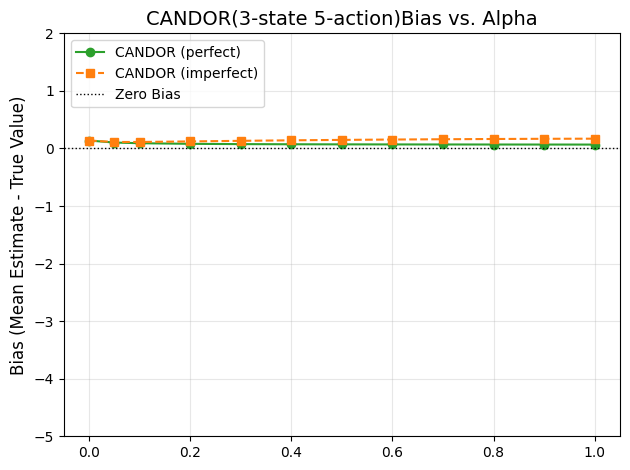

In [20]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
imperfect_data_max_budget = data['CANDOR_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CANDOR_perfect_estimates'][:, :, -1]

imperfect_bias = np.mean(imperfect_data_max_budget, axis=0) - true_value
perfect_bias = np.mean(perfect_data_max_budget, axis=0) - true_value

plt.plot(alphas, perfect_bias, marker='o', linestyle='-', color='#2ca02c', label='CANDOR (perfect)')
plt.plot(alphas, imperfect_bias, marker='s', linestyle='--', color='#ff7f0e', label='CANDOR (imperfect)')

plt.axhline(y=0, color='black', linestyle=':', linewidth=1, label='Zero Bias')

plt.title(f'CANDOR(3-state 5-action)Bias vs. Alpha', fontsize=14)
plt.ylabel('Bias (Mean Estimate - True Value)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-5, 2])
plt.tight_layout()
plt.savefig('CANDOR_Bias_Alpha.png', dpi=300)
plt.show()

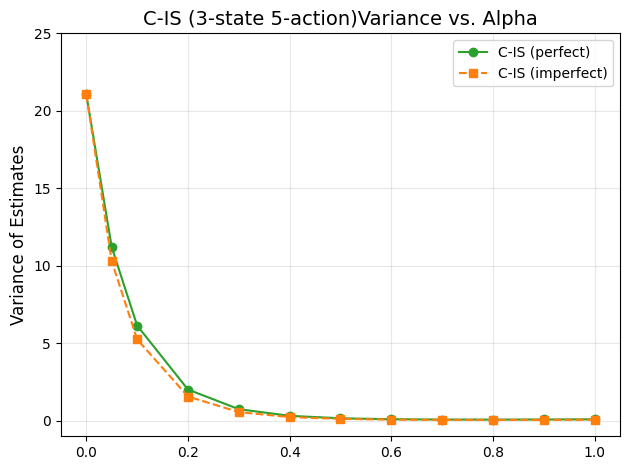

In [23]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
imperfect_data_max_budget = data['CPDIS_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CPDIS_perfect_estimates'][:, :, -1]

# Variance = Var(V_hat)
imperfect_var = np.var(imperfect_data_max_budget, axis=0)
perfect_var = np.var(perfect_data_max_budget, axis=0)

plt.plot(alphas, perfect_var, marker='o', linestyle='-', color='#2ca02c', label='C-IS (perfect)')
plt.plot(alphas, imperfect_var, marker='s', linestyle='--', color='#ff7f0e', label='C-IS (imperfect)')

plt.title(f'C-IS (3-state 5-action)Variance vs. Alpha', fontsize=14)
plt.ylabel('Variance of Estimates', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-1, 25])
plt.tight_layout()
plt.savefig('CIS_Variance_Alpha.png', dpi=300)
plt.show()

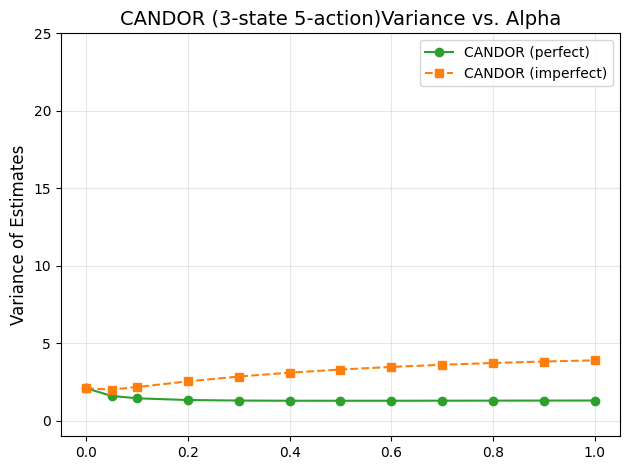

In [24]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
imperfect_data_max_budget = data['CANDOR_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CANDOR_perfect_estimates'][:, :, -1]

# Variance = Var(V_hat)
imperfect_var = np.var(imperfect_data_max_budget, axis=0)
perfect_var = np.var(perfect_data_max_budget, axis=0)

plt.plot(alphas, perfect_var, marker='o', linestyle='-', color='#2ca02c', label='CANDOR (perfect)')
plt.plot(alphas, imperfect_var, marker='s', linestyle='--', color='#ff7f0e', label='CANDOR (imperfect)')

plt.title(f'CANDOR (3-state 5-action)Variance vs. Alpha', fontsize=14)
plt.ylabel('Variance of Estimates', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-1, 25])
plt.tight_layout()
plt.savefig('CANDOR_Variance_Alpha.png', dpi=300)
plt.show()

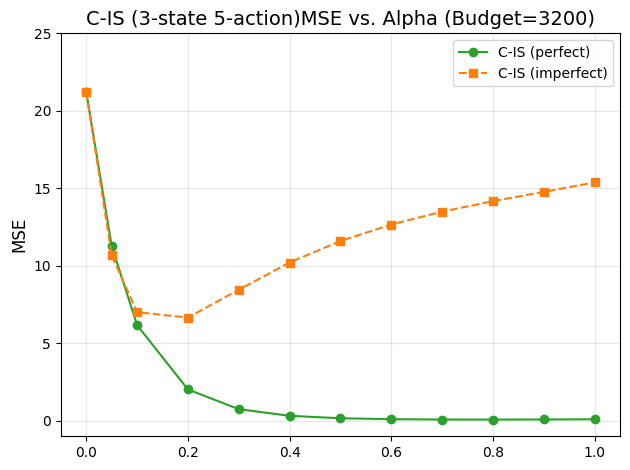

In [27]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
alphas = data['alphas']
true_value = data['true_value']
imperfect_data_max_budget = data['CPDIS_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CPDIS_perfect_estimates'][:, :, -1]

imperfect_bias = np.mean(imperfect_data_max_budget, axis=0) - true_value
perfect_bias = np.mean(perfect_data_max_budget, axis=0) - true_value
imperfect_var = np.var(imperfect_data_max_budget, axis=0)
perfect_var = np.var(perfect_data_max_budget, axis=0)

# MSE = var + bias^2
imperfect_mse = (imperfect_bias**2) + imperfect_var
perfect_mse = (perfect_bias**2) + perfect_var

plt.plot(alphas, perfect_mse, marker='o', linestyle='-', color='#2ca02c', label='C-IS (perfect)')
plt.plot(alphas, imperfect_mse, marker='s', linestyle='--', color='#ff7f0e', label='C-IS (imperfect)')

plt.title(f'C-IS (3-state 5-action)MSE vs. Alpha (Budget={data["budgets"][-1]})', fontsize=14)
plt.ylabel('MSE', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='-', alpha=0.3)
plt.ylim([-1,25])

plt.tight_layout()
plt.savefig('CIS_MSE_Alpha.png', dpi=300)
plt.show()

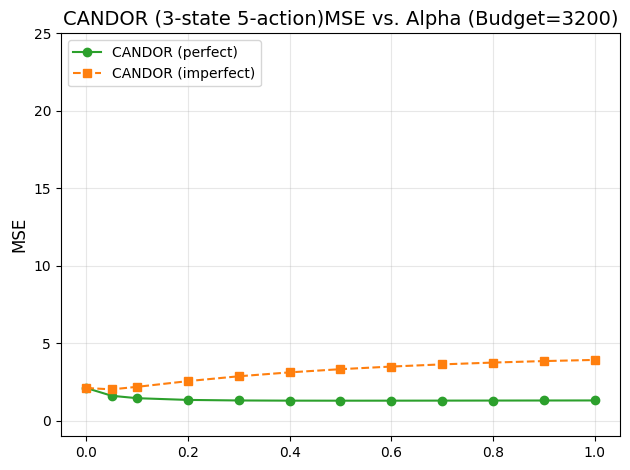

In [28]:
data = np.load('boxplot_data_mdp.npz', allow_pickle=True)
alphas = data['alphas']
true_value = data['true_value']
imperfect_data_max_budget = data['CANDOR_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CANDOR_perfect_estimates'][:, :, -1]

imperfect_bias = np.mean(imperfect_data_max_budget, axis=0) - true_value
perfect_bias = np.mean(perfect_data_max_budget, axis=0) - true_value
imperfect_var = np.var(imperfect_data_max_budget, axis=0)
perfect_var = np.var(perfect_data_max_budget, axis=0)

# MSE = var + bias^2
imperfect_mse = (imperfect_bias**2) + imperfect_var
perfect_mse = (perfect_bias**2) + perfect_var

plt.plot(alphas, perfect_mse, marker='o', linestyle='-', color='#2ca02c', label='CANDOR (perfect)')
plt.plot(alphas, imperfect_mse, marker='s', linestyle='--', color='#ff7f0e', label='CANDOR (imperfect)')

plt.title(f'CANDOR (3-state 5-action)MSE vs. Alpha (Budget={data["budgets"][-1]})', fontsize=14)
plt.ylabel('MSE', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='-', alpha=0.3)
plt.ylim([-1,25])

plt.tight_layout()
plt.savefig('CANDOR_MSE_Alpha.png', dpi=300)
plt.show()